# 03 — Santa Barbara County

Produces six figures:
- **Figure 11**: SB county restored sites by water type (1860–1980)
- **Figure 12**: SB county restored sites by decade (multi-panel)
- **Figures 13–15**: NWIS vs. restored groundwater sites (time series, by decade, combined map)
- **Figures 16–18**: NWIS vs. restored stream discharge sites (time series, by decade, combined map)

Requires:
- `data/analysis/processed_metadata.parquet` (output of `00_data_prep.ipynb`)
- `data/analysis/spatial/sb_county_shapefile/sb_county_shp.shp`
- `data/analysis/nwis_sites/sb_groundwater_sites_summary.csv` — pre-downloaded NWIS groundwater sites
- `data/analysis/nwis_sites/sb_streamflow_sites.csv` — pre-downloaded NWIS stream discharge sites

In [11]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import sys
sys.path.insert(0, str(Path('.')))
from water_palette import CATEGORY_ORDER, get_color_for

root         = Path('../..')
parquet_path = root / 'data/analysis/processed_metadata.parquet'
spatial_path = root / 'data/analysis/spatial'
nwis_path    = root / 'data/analysis/nwis_sites'
figures_path = root / 'manuscript/figures'
figures_path.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(parquet_path)
print(f'Loaded {len(df):,} rows')

Loaded 109,440 rows


## Filter to Santa Barbara County

In [12]:
WATER_CATEGORIES = [
    'Stream Discharge', 'Groundwater', 'Reservoir',
    'Irrigation', 'Springs', 'Precipitation', 'Water Quality'
]

sb_boundary = gpd.read_file(spatial_path / 'sb_county_shapefile/sb_county_shp.shp').to_crs('EPSG:4326')

df_geo = df[
    df['lat_combined'].notna() &
    df['lon_combined'].notna() &
    df['water_type_clean'].isin(WATER_CATEGORIES)
].drop_duplicates(subset=['lat_combined', 'lon_combined', 'water_type_clean'])

gdf_all = gpd.GeoDataFrame(
    df_geo,
    geometry=gpd.points_from_xy(df_geo['lon_combined'], df_geo['lat_combined']),
    crs='EPSG:4326'
)

gdf_sb = gpd.sjoin(gdf_all, sb_boundary[['geometry']], how='inner', predicate='within')
print(f'{len(gdf_sb):,} unique location/water-type points in Santa Barbara County')
print(gdf_sb['water_type_clean'].value_counts())

3,000 unique location/water-type points in Santa Barbara County
water_type_clean
Stream Discharge    1444
Groundwater         1092
Springs              255
Irrigation            98
Reservoir             68
Precipitation         39
Water Quality          4
Name: count, dtype: int64


## Figure 11 — SB sites by water type

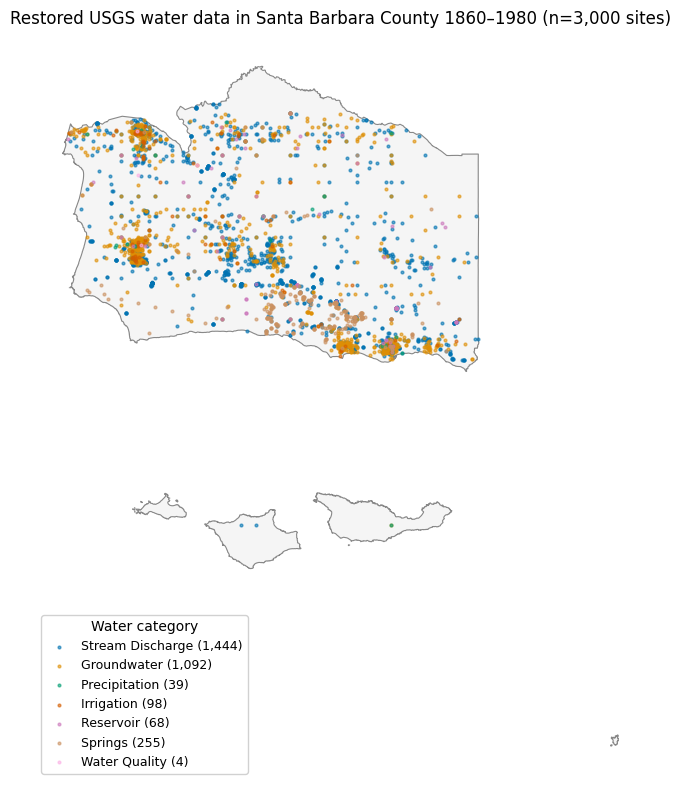

In [13]:
cols_ordered = [c for c in CATEGORY_ORDER if c in gdf_sb['water_type_clean'].unique()]

fig, ax = plt.subplots(figsize=(8, 8))
sb_boundary.plot(ax=ax, color='#f5f5f5', edgecolor='#888888', linewidth=0.8)

for wtype in cols_ordered:
    sub = gdf_sb[gdf_sb['water_type_clean'] == wtype]
    sub.plot(ax=ax, color=get_color_for(wtype), markersize=4, alpha=0.6,
             marker='o', label=f'{wtype} ({len(sub):,})')

ax.set_axis_off()
ax.legend(title='Water category', loc='lower left', fontsize=9, framealpha=0.9)
ax.set_title(f'Restored USGS water data in Santa Barbara County 1860–1980 (n={len(gdf_sb):,} sites)', fontsize=12)

plt.tight_layout()
plt.savefig(figures_path / 'sb_sites_by_water_type.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 12 — SB sites by decade

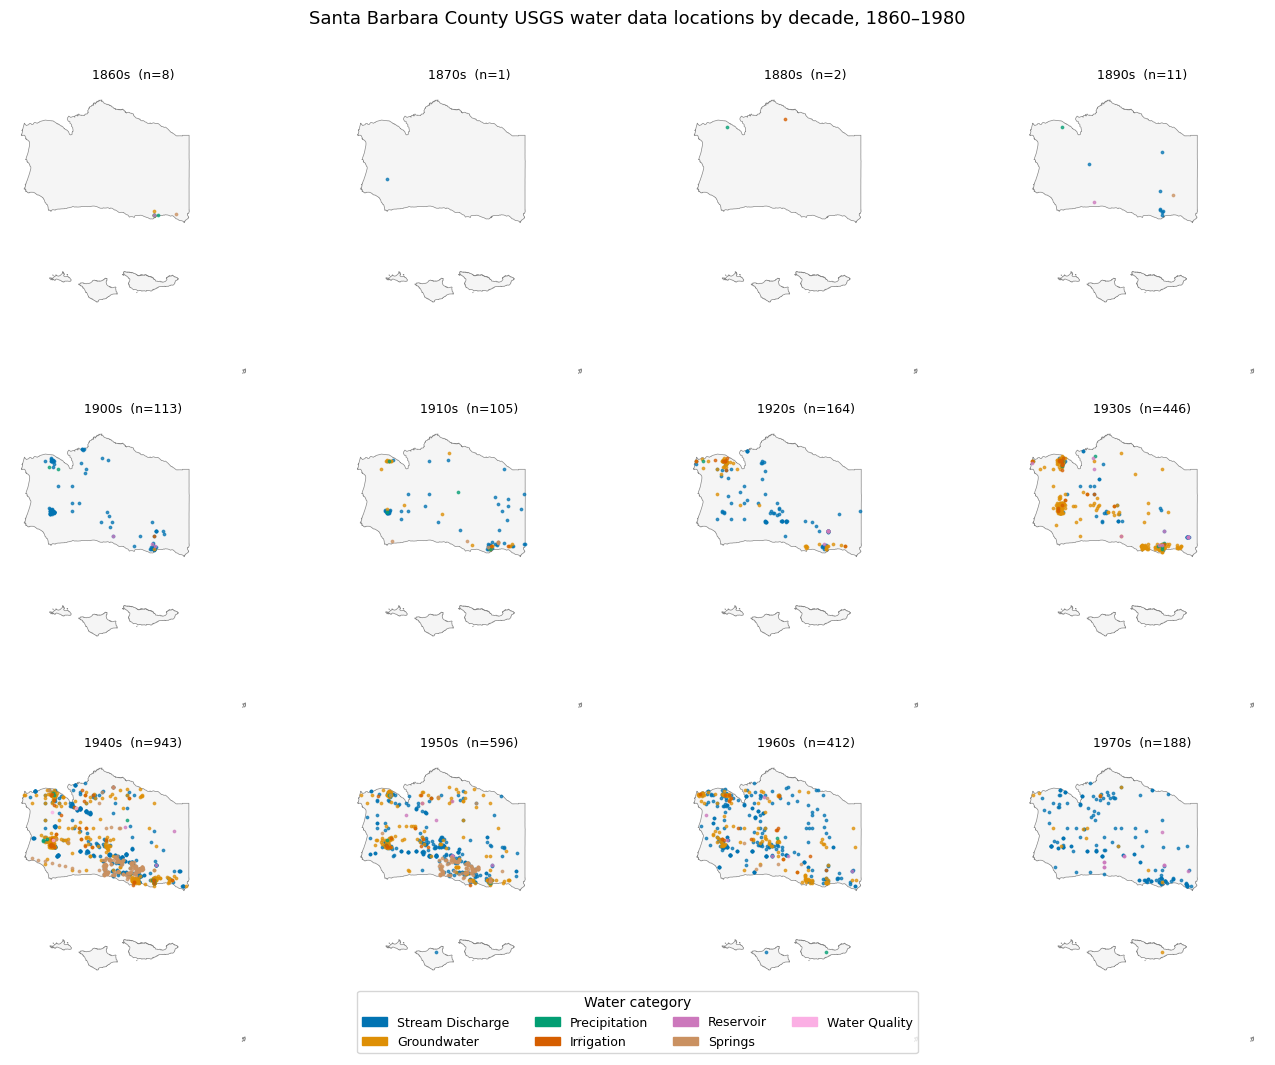

In [14]:
df_decade = df[
    df['lat_combined'].notna() &
    df['lon_combined'].notna() &
    df['water_type_clean'].isin(WATER_CATEGORIES) &
    df['decade_start'].notna()
].drop_duplicates(subset=['lat_combined', 'lon_combined', 'water_type_clean', 'decade_start'])

gdf_d = gpd.GeoDataFrame(
    df_decade,
    geometry=gpd.points_from_xy(df_decade['lon_combined'], df_decade['lat_combined']),
    crs='EPSG:4326'
)
gdf_sb_d = gpd.sjoin(gdf_d, sb_boundary[['geometry']], how='inner', predicate='within')

decades = sorted(gdf_sb_d['decade_start'].dropna().unique().astype(int))
decades = [d for d in decades if 1800 <= d <= 1980]

n_cols = 4
n_rows = -(-len(decades) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, decade in enumerate(decades):
    ax = axes[i]
    sb_boundary.plot(ax=ax, color='#f5f5f5', edgecolor='#888888', linewidth=0.5)
    sub = gdf_sb_d[gdf_sb_d['decade_start'] == decade]
    for wtype in cols_ordered:
        pts = sub[sub['water_type_clean'] == wtype]
        if not pts.empty:
            pts.plot(ax=ax, color=get_color_for(wtype), markersize=3, alpha=0.7, marker='o')
    ax.set_title(f'{decade}s  (n={len(sub):,})', fontsize=9)
    ax.set_axis_off()

for j in range(len(decades), len(axes)):
    axes[j].set_visible(False)

legend_handles = [mpatches.Patch(color=get_color_for(w), label=w) for w in cols_ordered]
fig.legend(handles=legend_handles, title='Water category',
           loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, 0.01))
fig.suptitle('Santa Barbara County USGS water data locations by decade, 1860–1980', fontsize=13, y=1.01)

plt.tight_layout()
plt.savefig(figures_path / 'sb_sites_by_decade.png', dpi=300, bbox_inches='tight')
plt.show()

## NWIS comparison — Groundwater

Loads pre-downloaded NWIS groundwater sites from `data/analysis/nwis_sites/sb_groundwater_sites_summary.csv` if it exists. If not, queries the USGS NWIS API (requires `pip install dataretrieval`) and saves the result for future runs.

In [15]:
gw_path = nwis_path / 'sb_groundwater_sites_summary.csv'

if gw_path.exists():
    gw_sites = pd.read_csv(gw_path)
    print(f'Loaded {len(gw_sites):,} NWIS groundwater sites from file')
else:
    from dataretrieval import nwis
    gw_sites, _ = nwis.what_sites(
        stateCd='CA', countyCd='06083', siteType='GW'
    )
    gw_sites = gw_sites.rename(columns={'dec_lat_va': 'latitude', 'dec_long_va': 'longitude',
                                         'station_nm': 'station_name'})
    if 'begin_date' in gw_sites.columns:
        gw_sites['start_year'] = pd.to_datetime(gw_sites['begin_date'], errors='coerce').dt.year
    if 'end_date' in gw_sites.columns:
        gw_sites['end_year'] = pd.to_datetime(gw_sites['end_date'], errors='coerce').dt.year
    gw_path.parent.mkdir(parents=True, exist_ok=True)
    gw_sites.to_csv(gw_path, index=False)
    print(f'Downloaded and saved {len(gw_sites):,} NWIS groundwater sites')

gw_sites['decade_nwis'] = (gw_sites['start_year'] // 10 * 10).astype('Int64')
gw_sites_geo = gpd.GeoDataFrame(
    gw_sites,
    geometry=gpd.points_from_xy(gw_sites['longitude'], gw_sites['latitude']),
    crs='EPSG:4326'
)
print(f'\nDecade distribution:')
print(gw_sites_geo['decade_nwis'].value_counts().sort_index())

Loaded 4,289 NWIS groundwater sites from file

Decade distribution:
decade_nwis
1900       5
1910       5
1920      81
1930     337
1940    1351
1950     896
1960     539
1970     580
1980     220
1990     135
2000      75
2010      60
2020       5
Name: count, dtype: Int64


## Figure 13 — Groundwater time series (NWIS vs restored)

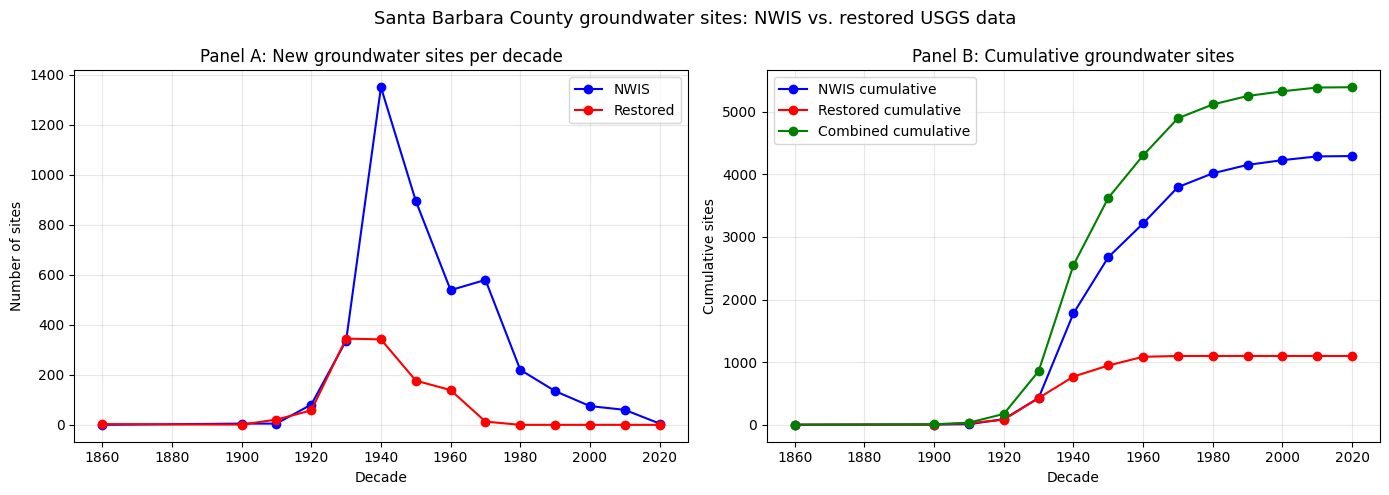

In [16]:
restored_gw = gdf_sb_d[gdf_sb_d['water_type_clean'] == 'Groundwater']

# Count unique sites per decade
nwis_gw_by_decade   = gw_sites_geo.groupby('decade_nwis').size().reset_index(name='nwis_count')
restored_gw_by_decade = restored_gw.groupby('decade_start').size().reset_index(name='restored_count')

# Merge for plotting
decade_df = pd.merge(
    nwis_gw_by_decade.rename(columns={'decade_nwis': 'decade'}),
    restored_gw_by_decade.rename(columns={'decade_start': 'decade'}),
    on='decade', how='outer'
).sort_values('decade').fillna(0)
decade_df['nwis_cumsum']     = decade_df['nwis_count'].cumsum()
decade_df['restored_cumsum'] = decade_df['restored_count'].cumsum()
decade_df['combined_cumsum'] = decade_df['nwis_cumsum'] + decade_df['restored_cumsum']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: count per decade
ax1.plot(decade_df['decade'], decade_df['nwis_count'],    'b-o', label='NWIS')
ax1.plot(decade_df['decade'], decade_df['restored_count'],'r-o', label='Restored')
ax1.set_xlabel('Decade')
ax1.set_ylabel('Number of sites')
ax1.set_title('Panel A: New groundwater sites per decade')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel B: cumulative
ax2.plot(decade_df['decade'], decade_df['nwis_cumsum'],     'b-o', label='NWIS cumulative')
ax2.plot(decade_df['decade'], decade_df['restored_cumsum'], 'r-o', label='Restored cumulative')
ax2.plot(decade_df['decade'], decade_df['combined_cumsum'], 'g-o', label='Combined cumulative')
ax2.set_xlabel('Decade')
ax2.set_ylabel('Cumulative sites')
ax2.set_title('Panel B: Cumulative groundwater sites')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Santa Barbara County groundwater sites: NWIS vs. restored USGS data', fontsize=13)
plt.tight_layout()
plt.savefig(figures_path / 'sb_groundwater_time_series.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 14 — Groundwater by decade (NWIS vs restored, multi-panel)

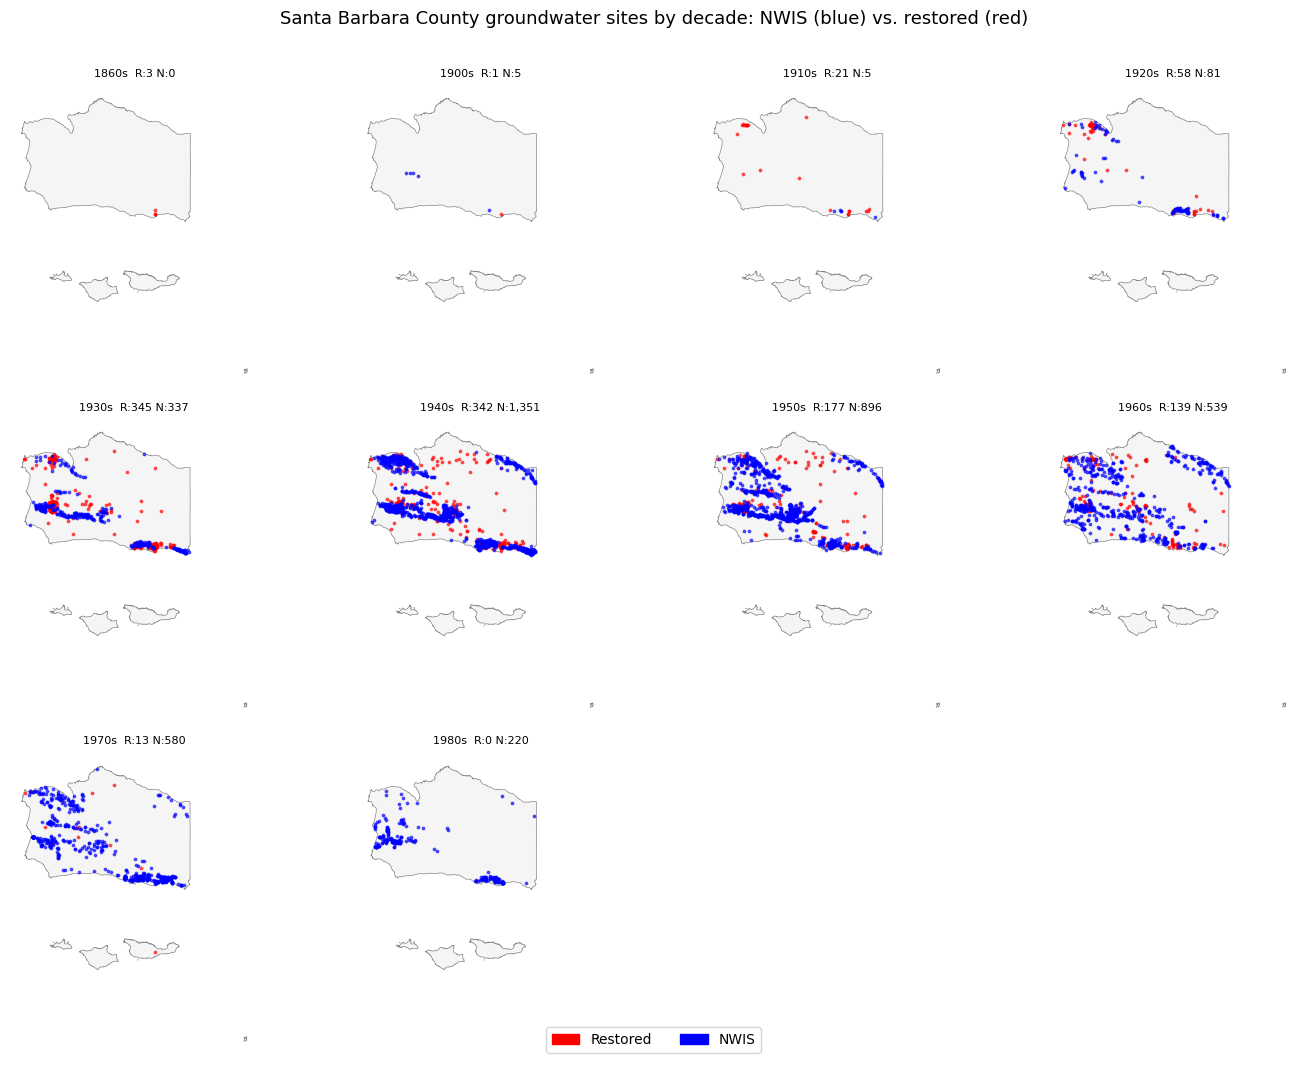

In [17]:
decades = sorted(set(
    list(nwis_gw_by_decade['decade_nwis'].dropna().astype(int)) +
    list(restored_gw['decade_start'].dropna().astype(int))
))
decades = [d for d in decades if 1800 <= d <= 1980]

n_cols = 4
n_rows = -(-len(decades) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, decade in enumerate(decades):
    ax = axes[i]
    sb_boundary.plot(ax=ax, color='#f5f5f5', edgecolor='#888888', linewidth=0.5)

    # Restored sites this decade
    r_pts = restored_gw[restored_gw['decade_start'] == decade]
    if not r_pts.empty:
        r_pts.plot(ax=ax, color='red', markersize=3, alpha=0.6, marker='o')

    # NWIS sites this decade
    n_pts = gw_sites_geo[gw_sites_geo['decade_nwis'] == decade]
    if not n_pts.empty:
        n_pts.plot(ax=ax, color='blue', markersize=3, alpha=0.6, marker='o')

    ax.set_title(f'{decade}s  R:{len(r_pts):,} N:{len(n_pts):,}', fontsize=8)
    ax.set_axis_off()

for j in range(len(decades), len(axes)):
    axes[j].set_visible(False)

legend_handles = [
    mpatches.Patch(color='red',  label='Restored'),
    mpatches.Patch(color='blue', label='NWIS'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, 0.01))
fig.suptitle('Santa Barbara County groundwater sites by decade: NWIS (blue) vs. restored (red)', fontsize=13, y=1.01)

plt.tight_layout()
plt.savefig(figures_path / 'sb_groundwater_by_decade.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 15 — Groundwater combined map (NWIS vs restored)

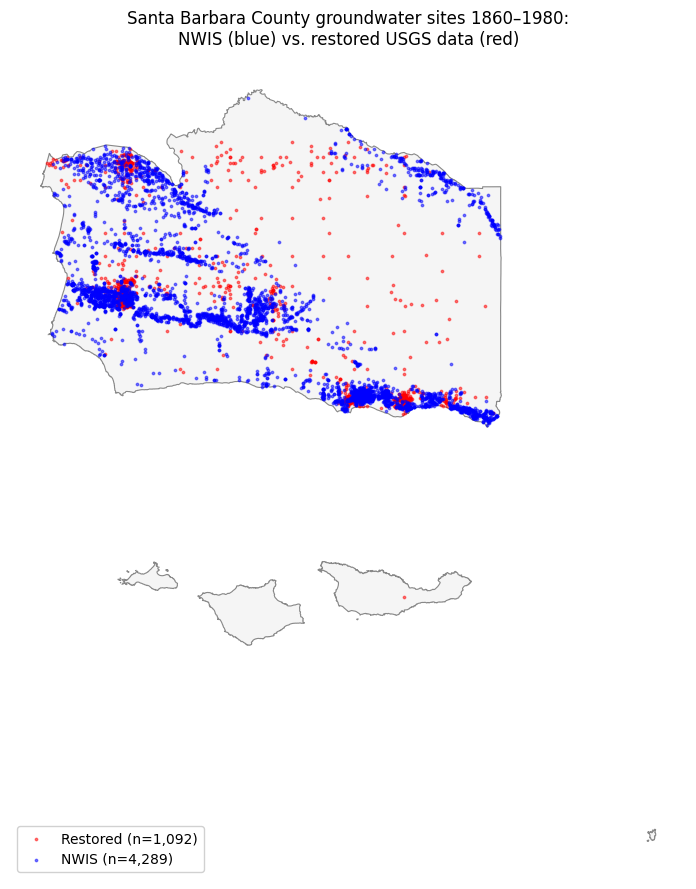

In [18]:
fig, ax = plt.subplots(figsize=(9, 9))
sb_boundary.plot(ax=ax, color='#f5f5f5', edgecolor='#888888', linewidth=0.8)

restored_gw_all = gdf_sb[gdf_sb['water_type_clean'] == 'Groundwater']
restored_gw_all.plot(ax=ax, color='red',  markersize=3, alpha=0.5, marker='o',
                     label=f'Restored (n={len(restored_gw_all):,})')
gw_sites_geo.plot(ax=ax, color='blue', markersize=3, alpha=0.5, marker='o',
                  label=f'NWIS (n={len(gw_sites_geo):,})')

ax.set_axis_off()
ax.legend(loc='lower left', fontsize=10, framealpha=0.9)
ax.set_title('Santa Barbara County groundwater sites 1860–1980:\nNWIS (blue) vs. restored USGS data (red)', fontsize=12)

plt.tight_layout()
plt.savefig(figures_path / 'sb_groundwater_map.png', dpi=300, bbox_inches='tight')
plt.show()

## NWIS comparison — Stream discharge

Loads pre-downloaded NWIS stream discharge sites from `data/analysis/nwis_sites/sb_streamflow_sites.csv` if it exists. If not, queries the USGS NWIS API and saves the result.

In [19]:
stream_path = nwis_path / 'sb_streamflow_sites.csv'

if stream_path.exists():
    stream_sites = pd.read_csv(stream_path)
    print(f'Loaded {len(stream_sites):,} NWIS stream sites from file')
else:
    from dataretrieval import nwis
    stream_sites, _ = nwis.what_sites(
        stateCd='CA', countyCd='06083', siteType='ST'
    )
    stream_sites = stream_sites.rename(columns={'dec_lat_va': 'latitude', 'dec_long_va': 'longitude',
                                                  'station_nm': 'station_name'})
    if 'begin_date' in stream_sites.columns:
        stream_sites['start_year'] = pd.to_datetime(stream_sites['begin_date'], errors='coerce').dt.year
    if 'end_date' in stream_sites.columns:
        stream_sites['end_year'] = pd.to_datetime(stream_sites['end_date'], errors='coerce').dt.year
    stream_path.parent.mkdir(parents=True, exist_ok=True)
    stream_sites.to_csv(stream_path, index=False)
    print(f'Downloaded and saved {len(stream_sites):,} NWIS stream sites')

stream_sites['decade_nwis'] = (stream_sites['start_year'] // 10 * 10).astype('Int64')
stream_sites_geo = gpd.GeoDataFrame(
    stream_sites,
    geometry=gpd.points_from_xy(stream_sites['longitude'], stream_sites['latitude']),
    crs='EPSG:4326'
)

Loaded 21 NWIS stream sites from file


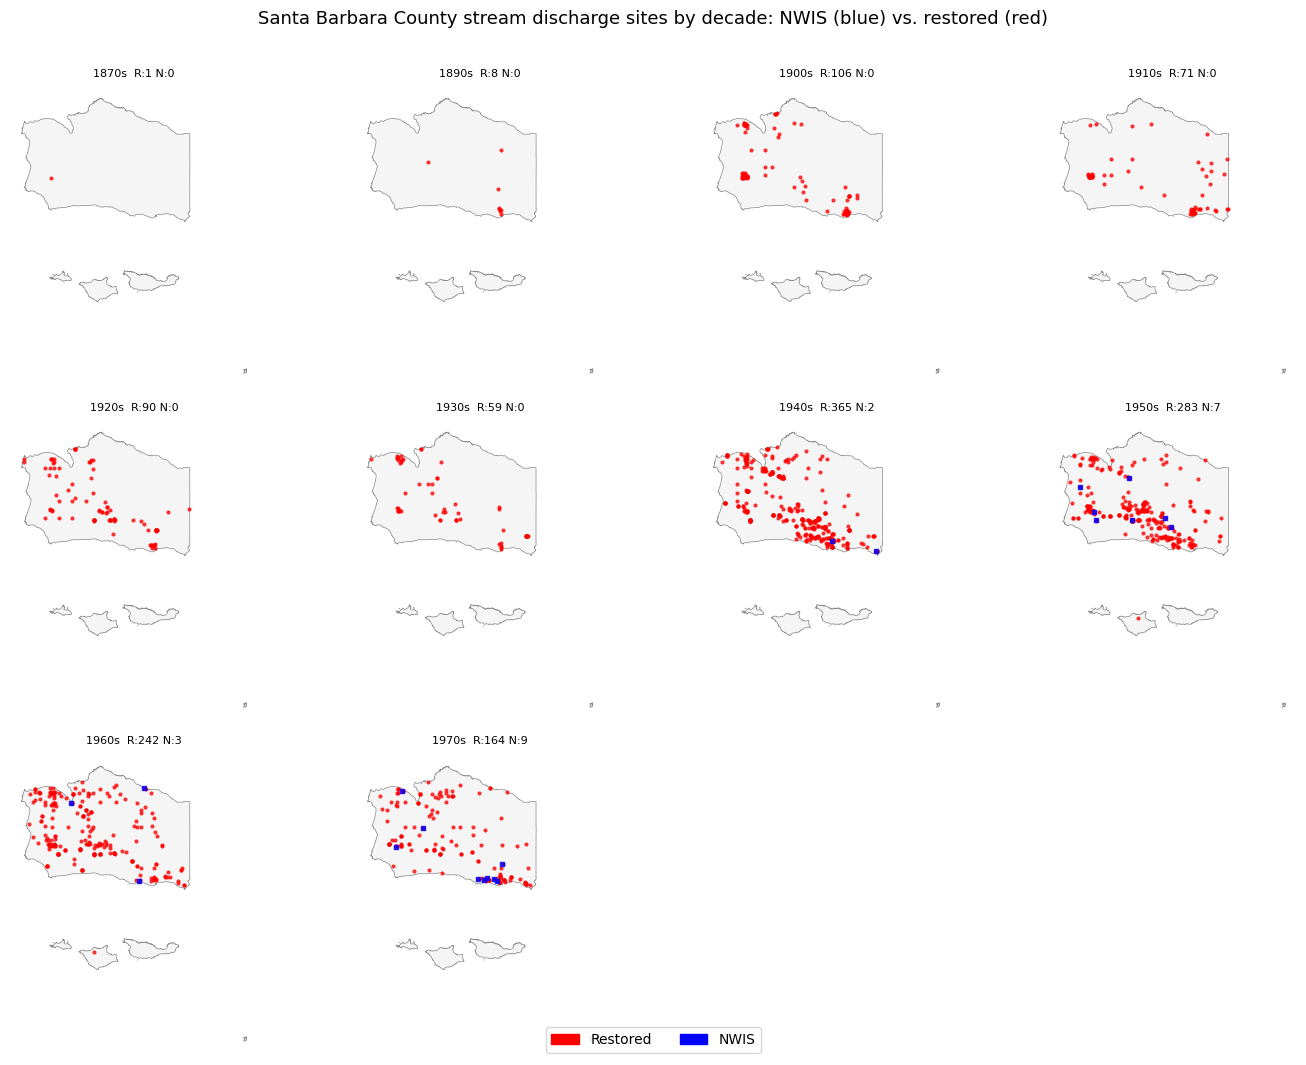

In [20]:
restored_sd = gdf_sb_d[gdf_sb_d['water_type_clean'] == 'Stream Discharge']

decades_sd = sorted(set(
    list(stream_sites['decade_nwis'].dropna().astype(int)) +
    list(restored_sd['decade_start'].dropna().astype(int))
))
decades_sd = [d for d in decades_sd if 1800 <= d <= 1980]

n_cols = 4
n_rows = -(-len(decades_sd) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, decade in enumerate(decades_sd):
    ax = axes[i]
    sb_boundary.plot(ax=ax, color='#f5f5f5', edgecolor='#888888', linewidth=0.5)
    r_pts = restored_sd[restored_sd['decade_start'] == decade]
    if not r_pts.empty:
        r_pts.plot(ax=ax, color='red', markersize=4, alpha=0.7, marker='o')
    n_pts = stream_sites_geo[stream_sites_geo['decade_nwis'] == decade]
    if not n_pts.empty:
        n_pts.plot(ax=ax, color='blue', markersize=5, alpha=0.8, marker='s')
    ax.set_title(f'{decade}s  R:{len(r_pts):,} N:{len(n_pts):,}', fontsize=8)
    ax.set_axis_off()

for j in range(len(decades_sd), len(axes)):
    axes[j].set_visible(False)

legend_handles = [
    mpatches.Patch(color='red',  label='Restored'),
    mpatches.Patch(color='blue', label='NWIS'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, 0.01))
fig.suptitle('Santa Barbara County stream discharge sites by decade: NWIS (blue) vs. restored (red)', fontsize=13, y=1.01)

plt.tight_layout()
plt.savefig(figures_path / 'sb_streamflow_by_decade.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 17 — Stream discharge time series (NWIS vs restored)

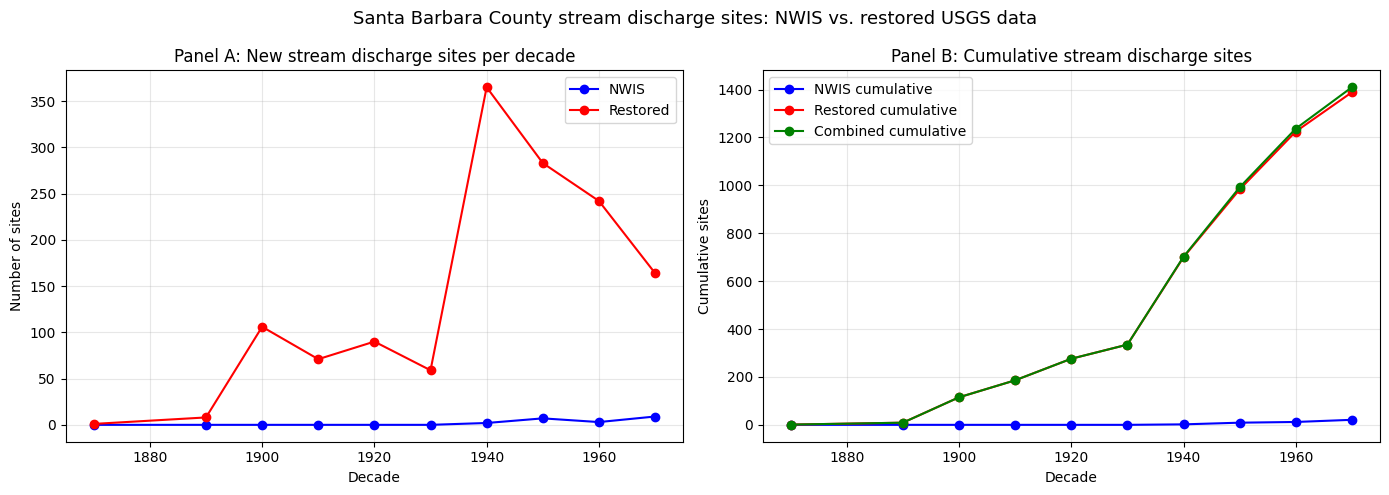

In [21]:
nwis_sd_by_decade     = stream_sites.groupby('decade_nwis').size().reset_index(name='nwis_count')
restored_sd_by_decade = restored_sd.groupby('decade_start').size().reset_index(name='restored_count')

decade_sd_df = pd.merge(
    nwis_sd_by_decade.rename(columns={'decade_nwis': 'decade'}),
    restored_sd_by_decade.rename(columns={'decade_start': 'decade'}),
    on='decade', how='outer'
).sort_values('decade').fillna(0)
decade_sd_df['nwis_cumsum']     = decade_sd_df['nwis_count'].cumsum()
decade_sd_df['restored_cumsum'] = decade_sd_df['restored_count'].cumsum()
decade_sd_df['combined_cumsum'] = decade_sd_df['nwis_cumsum'] + decade_sd_df['restored_cumsum']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(decade_sd_df['decade'], decade_sd_df['nwis_count'],    'b-o', label='NWIS')
ax1.plot(decade_sd_df['decade'], decade_sd_df['restored_count'],'r-o', label='Restored')
ax1.set_xlabel('Decade')
ax1.set_ylabel('Number of sites')
ax1.set_title('Panel A: New stream discharge sites per decade')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(decade_sd_df['decade'], decade_sd_df['nwis_cumsum'],     'b-o', label='NWIS cumulative')
ax2.plot(decade_sd_df['decade'], decade_sd_df['restored_cumsum'], 'r-o', label='Restored cumulative')
ax2.plot(decade_sd_df['decade'], decade_sd_df['combined_cumsum'], 'g-o', label='Combined cumulative')
ax2.set_xlabel('Decade')
ax2.set_ylabel('Cumulative sites')
ax2.set_title('Panel B: Cumulative stream discharge sites')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Santa Barbara County stream discharge sites: NWIS vs. restored USGS data', fontsize=13)
plt.tight_layout()
plt.savefig(figures_path / 'sb_streamflow_time_series.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 18 — Stream discharge combined map (NWIS vs restored)

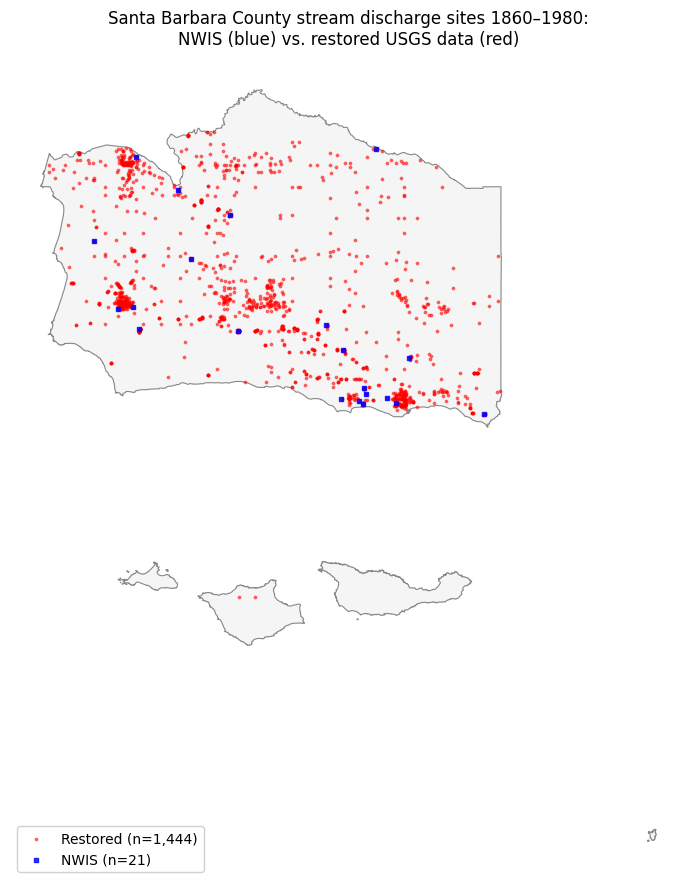

In [22]:
restored_sd_all = gdf_sb[gdf_sb['water_type_clean'] == 'Stream Discharge']

fig, ax = plt.subplots(figsize=(9, 9))
sb_boundary.plot(ax=ax, color='#f5f5f5', edgecolor='#888888', linewidth=0.8)
restored_sd_all.plot(ax=ax, color='red',  markersize=3, alpha=0.5, marker='o',
                     label=f'Restored (n={len(restored_sd_all):,})')
stream_sites_geo.plot(ax=ax, color='blue', markersize=6, alpha=0.8, marker='s',
                      label=f'NWIS (n={len(stream_sites_geo):,})')

ax.set_axis_off()
ax.legend(loc='lower left', fontsize=10, framealpha=0.9)
ax.set_title('Santa Barbara County stream discharge sites 1860–1980:\nNWIS (blue) vs. restored USGS data (red)', fontsize=12)

plt.tight_layout()
plt.savefig(figures_path / 'sb_streamflow_map.png', dpi=300, bbox_inches='tight')
plt.show()